# FINAL PROJECT

**Deliverables**:
  1. Your version of this notebook, where you create the required agents (complete all the associated tasks)

  2. After training your agents, you might want to save those learnt values. This can be a dictionary with the `optimal policy`, or `Q-values`. If an approximate method was used, you can provide the `final weights`, etc.

  3. A short report (no more than 10 pages), where you explain your methodology, chosen parameters, visualisations of the learning process (how rewards increase over time, or how loss functions decrease).

  4. Upload to `Faser` a .zip file of all the deliverables (including th optimal Q-values/weights/policies)

**Evaluation**: Your projects will be evaluated primarily on the development of the agents, not necessarily in their performance. Being said that, better performance will lead in general to better marks.

## 0. Setup

In [137]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym

from tqdm import tqdm

from src.logger import LogManager
from src.utils import (
    plot_learning_curve, plot_smoothed_learning_curve
)

In [138]:
manager = LogManager()

main_log = manager.get_logger("Main", "main.log")

In [139]:
env = gym.make("Acrobot-v1", render_mode = "rgb_array")
state = env.reset()

main_log.info("--- New Session Started ---")
main_log.info(f"Environment: Acrobot-v1")
main_log.info(f"Initial State: {state}")
main_log.info(f"State Space: {env.observation_space}")
main_log.info(f"Action Space: {env.action_space}")

2026-04-20 21:59:52 | INFO    | --- New Session Started ---
2026-04-20 21:59:52 | INFO    | Environment: Acrobot-v1
2026-04-20 21:59:52 | INFO    | Initial State: (array([ 0.9998127 , -0.01935163,  0.99531525, -0.09668275, -0.09878628,
       -0.0712266 ], dtype=float32), {})
2026-04-20 21:59:52 | INFO    | State Space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
2026-04-20 21:59:52 | INFO    | Action Space: Discrete(3)


## 1. Notebook Utilities

In [140]:
def save_nn_policy(net, name):
    path = f"models/{name}.pt"
    torch.save(net.state_dict(), path)
    main_log.info(f"NN model saved: {path}")

def load_nn_policy(name, n_actions=3, hidden=64):
    net = PolicyNetwork(input_dim=4, n_actions=n_actions, hidden=hidden)
    net.load_state_dict(torch.load(f"models/{name}.pt"))
    net.eval()
    return net

In [141]:
def transform_state(obs):
    """
    Uses the same arctan2 transform as discretise() but keeps it continuous.
    Returns a normalized 4D tensor ready for the network.
    """
    
    cos1, sin1, cos2, sin2, w1, w2 = obs
    theta1 = np.arctan2(sin1, cos1)
    theta2 = np.arctan2(sin2, cos2)

    # Normalize to [-1, 1] using same bounds as discretise()
    LOW = np.array([-np.pi, -np.pi, -6.0, -10.0])
    HIGH = np.array([ np.pi,  np.pi,  6.0,  10.0])

    state = np.array([theta1, theta2, w1, w2])
    normalized = 2.0 * (state - LOW) / (HIGH - LOW) - 1.0
    normalized = np.clip(normalized, -1.0, 1.0)
    
    return torch.FloatTensor(normalized)

In [142]:
class PolicyNetwork(nn.Module):
    """
    Shared-trunk actor-critic network.
    Input: 4D continuous state (theta1, theta2, w1, w2)
    Output: action logits + state value
    """
    def __init__(self, input_dim=4, n_actions=3, hidden=64):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden, n_actions)
        self.value_head  = nn.Linear(hidden, 1)

    def forward(self, x):
        features = self.trunk(x)
        return self.policy_head(features), self.value_head(features)

In [143]:
def evaluate_nn_policy(net, n_episodes = 20, seed = 42):
    env = gym.make("Acrobot-v1")
    rewards, steps = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        t = 0

        while not done:
            state_tensor = transform_state(obs)
            with torch.no_grad():
                logits, _ = net(state_tensor)
                probs  = F.softmax(logits, dim=-1)
                # action = torch.argmax(logits).item()
                dist   = torch.distributions.Categorical(probs)
                action = dist.sample()

            obs, reward, term, trunc, _ = env.step(action)
            total_reward += reward
            t += 1
            done = term or trunc

        rewards.append(total_reward)
        steps.append(t)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_steps": np.mean(steps),
        "success_rate": np.mean(np.array(steps) < 500)
    }

# Alg

In [144]:
def alg_REINFORCE_NN(env, params):
    """
    REINFORCE with baseline (NN) — Sutton & Barto Chapter 13.
    With practical stabilizations: loss weighting, entropy bonus, grad clipping.
    """
    seed = params["seed"]
    torch.manual_seed(seed)
    show_progress  = params["show_progress"]
    n_episodes     = params["n_episodes"]
    n_actions      = env.action_space.n
    gamma          = params["gamma"]
    lr_theta       = params["alpha_theta"]
    lr_w           = params["alpha_w"]
    entropy_coef   = params.get("entropy_coef", 0.01)
    value_coef     = params.get("value_coef", 0.5)

    net = PolicyNetwork(input_dim=4, n_actions=n_actions, hidden=64)
    optimizer = optim.Adam([
        {"params": list(net.trunk.parameters()) +
                   list(net.policy_head.parameters()), "lr": lr_theta},
        {"params": net.value_head.parameters(), "lr": lr_w},
    ])

    rewards_history = []
    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training REINFORCE-NN", leave=False)

    for ep in iterator:
        obs, _ = env.reset()
        ep_log_probs, ep_values, ep_rewards, ep_entropies = [], [], [], []
        done = False

        while not done:
            state_tensor = transform_state(obs)
            logits, value = net(state_tensor)
            probs  = F.softmax(logits, dim=-1)
            dist   = torch.distributions.Categorical(probs)
            action = dist.sample()

            ep_log_probs.append(dist.log_prob(action))
            ep_values.append(value.squeeze())
            ep_entropies.append(dist.entropy())

            obs, reward, term, trunc, _ = env.step(action.item())
            ep_rewards.append(reward)
            done = term or trunc

        rewards_history.append(sum(ep_rewards))

        T = len(ep_rewards)
        returns = np.zeros(T)
        G = 0.0
        for t in reversed(range(T)):
            G = ep_rewards[t] + gamma * G
            returns[t] = G
        returns  = torch.FloatTensor(returns)
        gamma_t  = torch.FloatTensor([gamma**t for t in range(T)])

        log_probs  = torch.stack(ep_log_probs)
        values     = torch.stack(ep_values)
        entropies  = torch.stack(ep_entropies)
        delta      = returns - values.detach()

        policy_loss  = -(gamma_t * delta * log_probs).mean()
        value_loss   = F.mse_loss(values, returns)
        entropy_loss = -entropies.mean()  # negative because we want to maximise entropy

        loss = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer.step()

    return net, rewards_history

# Eval

In [145]:
REINFORCE_NN_PARAMS = {
    "n_episodes": 5000,
    "gamma": 1.0,
    "seed": 42,
    "show_progress": True,
    "alpha_theta": 3e-4, 
    "alpha_w": 1e-3
}

In [146]:
# QUICK_PARAMS = {**REINFORCE_NN_PARAMS, "n_episodes": 200,}
# model, rewards = alg_REINFORCE_NN(env, params=QUICK_PARAMS)
# print(f"Last 20 episodes mean: {np.mean(rewards[-20:]):.1f}")
# # If this is above -450, the params are worth running to 2000 episodes
# # If it's near -500, try the next option

In [ ]:
# def diagnose_reinforce_nn(params, n_episodes=50):
#     
#     env_d = gym.make("Acrobot-v1")
#     torch.manual_seed(params["seed"])
    
#     net = PolicyNetwork(input_dim=4, n_actions=3, hidden=64)
#     optimizer = optim.Adam([
#         {"params": list(net.trunk.parameters()) + 
#                    list(net.policy_head.parameters()), 
#          "lr": params["alpha_theta"]},
#         {"params": net.value_head.parameters(), 
#          "lr": params["alpha_w"]},
#     ])
    
#     gamma = params["gamma"]
    
#     for ep in range(n_episodes):
#         obs, _ = env_d.reset()
#         ep_log_probs, ep_values, ep_rewards = [], [], []
#         done = False
        
#         while not done:
#             st = transform_state(obs)
#             logits, value = net(st)
#             probs = F.softmax(logits, dim=-1)
#             dist  = torch.distributions.Categorical(probs)
#             action = dist.sample()
#             ep_log_probs.append(dist.log_prob(action))
#             ep_values.append(value.squeeze())
#             obs, reward, term, trunc, _ = env_d.step(action.item())
#             ep_rewards.append(reward)
#             done = term or trunc
        
#         T = len(ep_rewards)
#         returns = np.zeros(T)
#         G = 0.0
#         for t in reversed(range(T)):
#             G = ep_rewards[t] + gamma * G
#             returns[t] = G

#         returns = (returns - returns.mean()) / (returns.std() + 1e-8)
#         returns = torch.FloatTensor(returns)
#         gamma_t = torch.FloatTensor([gamma**t for t in range(T)])
        
#         log_probs = torch.stack(ep_log_probs)
#         values    = torch.stack(ep_values)
#         delta     = returns - values.detach()
        
#         policy_loss = -(gamma_t * delta * log_probs).mean()
#         value_loss  = F.mse_loss(values, returns)
#         loss = policy_loss + value_loss
        
#         optimizer.zero_grad()
#         loss.backward()
        
#         # Capture gradient norms BEFORE clipping
#         policy_grad_norm = sum(
#             p.grad.norm().item()**2 
#             for p in list(net.trunk.parameters()) + 
#                      list(net.policy_head.parameters())
#             if p.grad is not None
#         ) ** 0.5
#         value_grad_norm = sum(
#             p.grad.norm().item()**2 
#             for p in net.value_head.parameters()
#             if p.grad is not None
#         ) ** 0.5
        
#         torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
#         optimizer.step()
        
#         if ep % 10 == 0:
#             with torch.no_grad():
#                 # Check action entropy — uniform = 1.099, deterministic = 0
#                 sample_obs, _ = env_d.reset()
#                 sample_logits, sample_val = net(transform_state(sample_obs))
#                 sample_probs = F.softmax(sample_logits, dim=-1)
#                 entropy = -(sample_probs * torch.log(sample_probs + 1e-8)).sum()
                
#             print(
#                 f"ep {ep:3d} | "
#                 f"reward {sum(ep_rewards):6.1f} | "
#                 f"T {T:4d} | "
#                 f"G_0 {returns[0].item():8.2f} | "
#                 f"v̂(s0) {values[0].item():8.2f} | "
#                 f"δ_mean {delta.mean().item():7.3f} | "
#                 f"p_loss {policy_loss.item():8.4f} | "
#                 f"v_loss {value_loss.item():8.2f} | "
#                 f"p_grad {policy_grad_norm:.4f} | "
#                 f"v_grad {value_grad_norm:.4f} | "
#                 f"entropy {entropy.item():.4f}"
#             )

# diagnose_reinforce_nn({
#     "seed": 42, "gamma": 1.0,
#     "alpha_theta": 1e-3, "alpha_w": 5e-3
# })

In [148]:
model, rewards = alg_REINFORCE_NN(env, params = REINFORCE_NN_PARAMS)

Training REINFORCE-NN:   0%|          | 0/5000 [00:00<?, ?it/s]

In [149]:
evaluate_nn_policy(model)

{'mean_reward': np.float64(-500.0),
 'std_reward': np.float64(0.0),
 'mean_steps': np.float64(500.0),
 'success_rate': np.float64(0.0)}

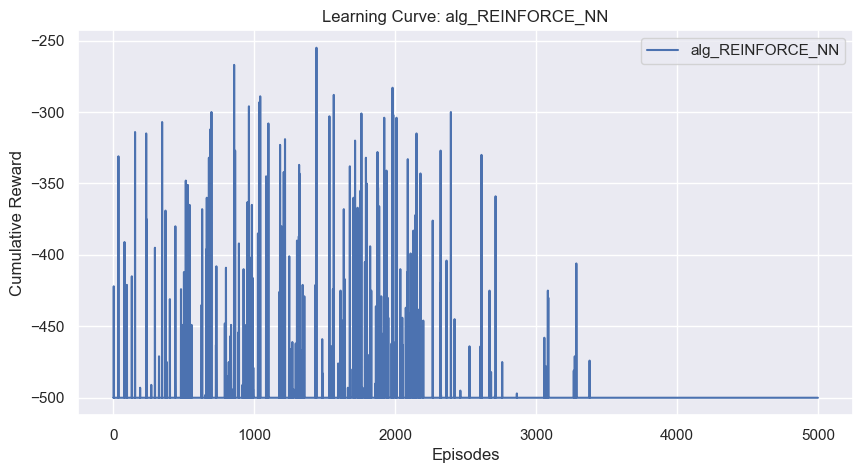

2026-04-20 23:28:46 | INFO    | Plot created in notebook.


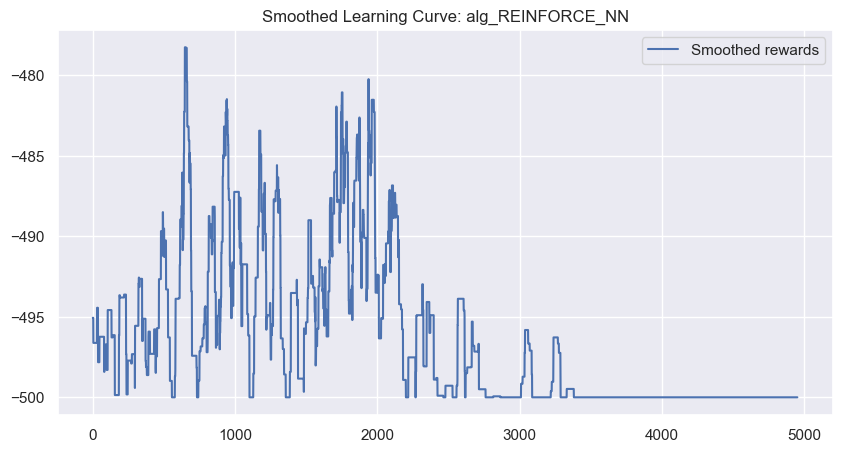

In [150]:
plot_learning_curve(rewards, alg_REINFORCE_NN.__name__)
plot_smoothed_learning_curve(rewards, alg_REINFORCE_NN.__name__)